# Logistic Regression using cleaned data
This notebook uses the helper `get_clean_X_y()` from `data_utils` (same pattern as `naiveBayes.ipynb`) so we don't re-run cleaning steps. We perform hyperparameter tuning for Logistic Regression with GridSearchCV and evaluate the best model.

In [14]:
# Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
sns.set()

In [15]:
# Load cleaned data from data_utils (reuses preprocessing from naiveBayes.ipynb)
from data_utils import get_clean_X_y
X, y = get_clean_X_y()
print('X shape:', X.shape)
print('y distribution:\n', y.value_counts())

X shape: (5644, 98)
y distribution:
 class
e    3488
p    2156
Name: count, dtype: int64


In [16]:
# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

Train shape: (4515, 98) Test shape: (1129, 98)


In [17]:
# Hyperparameter grid and GridSearchCV
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['saga', 'liblinear']
}

base = LogisticRegression(max_iter=1000, random_state=42)
grid = GridSearchCV(base, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print('Best params:', grid.best_params_)
print('Best CV score:', grid.best_score_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'C': 1, 'penalty': 'l1', 'solver': 'saga'}
Best CV score: 1.0


Retrained model: LogisticRegression(C=1, max_iter=1000, penalty='l1', random_state=42,
                   solver='saga')
Test accuracy: 1.0

Classification report:
               precision    recall  f1-score   support

           e       1.00      1.00      1.00       698
           p       1.00      1.00      1.00       431

    accuracy                           1.00      1129
   macro avg       1.00      1.00      1.00      1129
weighted avg       1.00      1.00      1.00      1129

Confusion matrix:
 [[698   0]
 [  0 431]]


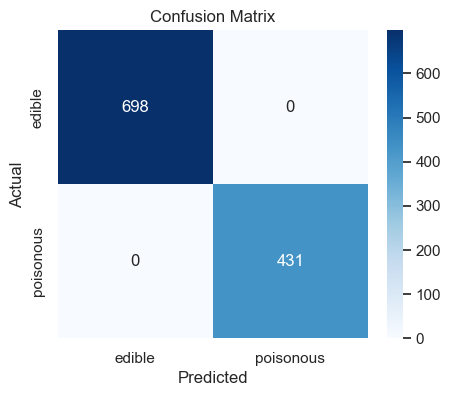

In [18]:
# Retrain best estimator on full training set (GridSearchCV refits by default), evaluate on test set
best = grid.best_estimator_
print('Retrained model:', best)
y_pred = best.predict(X_test)
print('Test accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification report:\n', classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix:\n', cm)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['edible','poisonous'], yticklabels=['edible','poisonous'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [19]:
# Optionally: save the best model for later use
import joblib
joblib.dump(best, 'logistic_best_model.joblib')
print('Saved model to logistic_best_model.joblib')

Saved model to logistic_best_model.joblib


Running nested CV (outer_cv=5, inner_cv=5) — this may take a while...
Nested CV accuracy: mean=1.0000, std=0.0000
Refitting GridSearchCV on full data to get final estimator...
Fitting 5 folds for each of 81 candidates, totalling 405 fits


c:\Users\NicoD\anaconda3\envs\ML\Lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


Best params on full data: {'C': 1.0, 'l1_ratio': 0.1, 'penalty': 'l1', 'solver': 'saga'}
Best inner-CV score on full data: 1.0
Saved final model to logistic_best_model_nested.joblib
Test accuracy (final model): 1.0

Classification report:
               precision    recall  f1-score   support

           e       1.00      1.00      1.00       698
           p       1.00      1.00      1.00       431

    accuracy                           1.00      1129
   macro avg       1.00      1.00      1.00      1129
weighted avg       1.00      1.00      1.00      1129



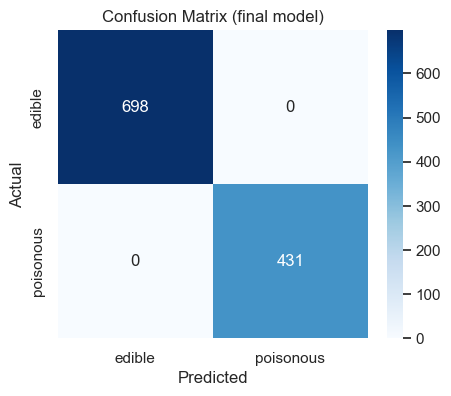

In [20]:
# Nested stratified cross-validation (outer CV for unbiased estimate) and expanded hyperparameter grid
from sklearn.model_selection import StratifiedKFold, cross_val_score
# inner CV used by GridSearch (for hyperparameter tuning)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# outer CV used by cross_val_score to get an unbiased generalization estimate
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

param_grid = {
    'C': np.logspace(-4, 4, 9),               # wide log-scale grid for regularization strength
    'penalty': ['l1', 'l2', 'elasticnet'],    # include elasticnet for combined L1/L2 smoothing
    'solver': ['saga'],                       # saga supports l1, l2, elasticnet
    'l1_ratio': [0.1, 0.5, 0.9]               # used only when penalty='elasticnet'
}

base = LogisticRegression(max_iter=2000, random_state=42)
grid_nested = GridSearchCV(base, param_grid, cv=inner_cv, scoring='accuracy', n_jobs=-1, verbose=2)

print(f"Running nested CV (outer_cv={outer_cv.get_n_splits()}, inner_cv={inner_cv.get_n_splits()}) — this may take a while...")
nested_scores = cross_val_score(grid_nested, X, y, cv=outer_cv, scoring='accuracy', n_jobs=-1)
print('Nested CV accuracy: mean={:.4f}, std={:.4f}'.format(nested_scores.mean(), nested_scores.std()))

# Refit GridSearch on the entire dataset (inner CV) to obtain final model
print('Refitting GridSearchCV on full data to get final estimator...')
grid_nested.fit(X, y)
print('Best params on full data:', grid_nested.best_params_)
print('Best inner-CV score on full data:', grid_nested.best_score_)

best_final = grid_nested.best_estimator_
joblib.dump(best_final, 'logistic_best_model_nested.joblib')
print('Saved final model to logistic_best_model_nested.joblib')

# Evaluate the final model on the held-out test set from the earlier stratified split
y_test_pred = best_final.predict(X_test)
print('Test accuracy (final model):', accuracy_score(y_test, y_test_pred))
print('\nClassification report:\n', classification_report(y_test, y_test_pred))
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['edible','poisonous'], yticklabels=['edible','poisonous'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (final model)')
plt.show()